# Setup

In [1]:
import os
import pickle
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
import pingouin as pg

sub_ids = [
    "M03", "M04", "M05", "M06", "M08", "M09", "M10", "M11", "M12", "M13",
    "M15", "M17", "M18", "M19", "M20", "M21", "M22", "M23", "M24", "M25",
    "M26", "M27", "M28", "M29", "M30"
]

within_reliable = True

# Fig. S1a. ROI-based representational similarity analysis results for all ROIs. 

# Fig. S1b — Split-half RSA reliability

{'evc_l': 0.000866493367993068, 'evc_r': 0.000866493367993068, 'mt_l': 0.000866493367993068, 'mt_r': 0.003465973471972272, 'psts_l': 0.002079584083183363, 'psts_r': 0.002079584083183363, 'asts_l': 0.7864427114577085, 'asts_r': 0.29374125174965005, 'tpj_l': 0.01884623075384923, 'tpj_r': 0.011883337618190647, 'dmpfc': 0.29374125174965005, 'mmpfc': 0.7864427114577085, 'vmpfc': 0.42300630782934323}


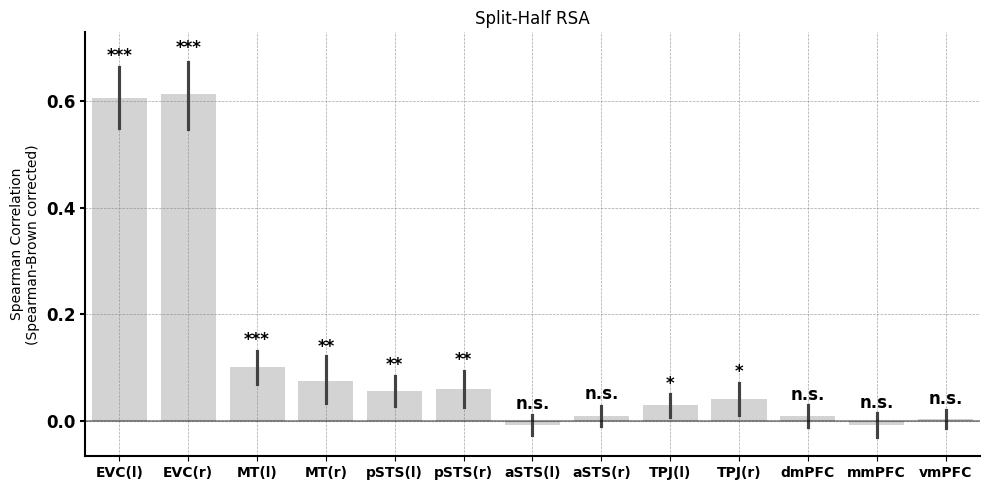

In [2]:
from roi_utils import signed_permutation_test_with_fdr, make_roiwise_boxplot

# Load split-half RSA values
with open("../derivatives/analyses/reliability/Mset_roiwise_splithalfrsa_withinreliable", "rb",) as f:
    split_half_rsa = pickle.load(f)

# Spearman-Brown correction
split_half_r_sb = {sub_id: {roi: 2 * r / (1 + r) for roi, r in roi_dict.items()} for sub_id, roi_dict in split_half_rsa.items()}

roi_order = ["evc_l", "evc_r", "mt_l", "mt_r", "psts_l", "psts_r", "asts_l", "asts_r", "tpj_l", "tpj_r", "dmpfc", "mmpfc", "vmpfc",]

split_half_r_sb_ord = {sub: {roi: split_half_r_sb[sub][roi] for roi in roi_order} for sub in sub_ids}

# Significance against zero, FDR-corrected across ROIs
reorganized_r = {roi: [split_half_r_sb_ord[sub][roi] for sub in sub_ids] for roi in roi_order}

_, p_fdr_corrected = signed_permutation_test_with_fdr(reorganized_r)
print(p_fdr_corrected)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

make_roiwise_boxplot(split_half_r_sb_ord, sub_ids, plot_title="Split-Half RSA", ax=ax, visualtype="bar", fdr_pvals=p_fdr_corrected,)

label_map = {
    "evc_l": "EVC(l)", "evc_r": "EVC(r)",
    "mt_l": "MT(l)", "mt_r": "MT(r)",
    "psts_l": "pSTS(l)", "psts_r": "pSTS(r)",
    "asts_l": "aSTS(l)", "asts_r": "aSTS(r)",
    "tpj_l": "TPJ(l)", "tpj_r": "TPJ(r)",
    "dmpfc": "dmPFC", "mmpfc": "mmPFC", "vmpfc": "vmPFC",
}

ax.set_xticklabels([label_map[r] for r in roi_order], rotation=0)

for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")

for bar in ax.patches:
    bar.set_facecolor("lightgray")

ax.set_xlabel("")
ax.set_ylabel("Spearman Correlation\n(Spearman-Brown corrected)")

plt.tight_layout()
plt.show()

# S2. Variance uniquely explained by SocialGNN, SIMPLE, and Human social ratings after controlling for Motion energy 

# S3. Variance uniquely explained by SocialGNN, SIMPLE, and Human social ratings after controlling for early visual cortex (EVC) responses  

M03: Loaded saved ROIs
M04: Loaded saved ROIs
M05: Loaded saved ROIs
M06: Loaded saved ROIs
M08: Loaded saved ROIs
M09: Loaded saved ROIs
M10: Loaded saved ROIs
M11: Loaded saved ROIs
M12: Loaded saved ROIs
M13: Loaded saved ROIs
M15: Loaded saved ROIs
M17: Loaded saved ROIs
M18: Loaded saved ROIs
M19: Loaded saved ROIs
M20: Loaded saved ROIs
M21: Loaded saved ROIs
M22: Loaded saved ROIs
M23: Loaded saved ROIs
M24: Loaded saved ROIs
M25: Loaded saved ROIs
M26: Loaded saved ROIs
M27: Loaded saved ROIs
M28: Loaded saved ROIs
M29: Loaded saved ROIs
M30: Loaded saved ROIs


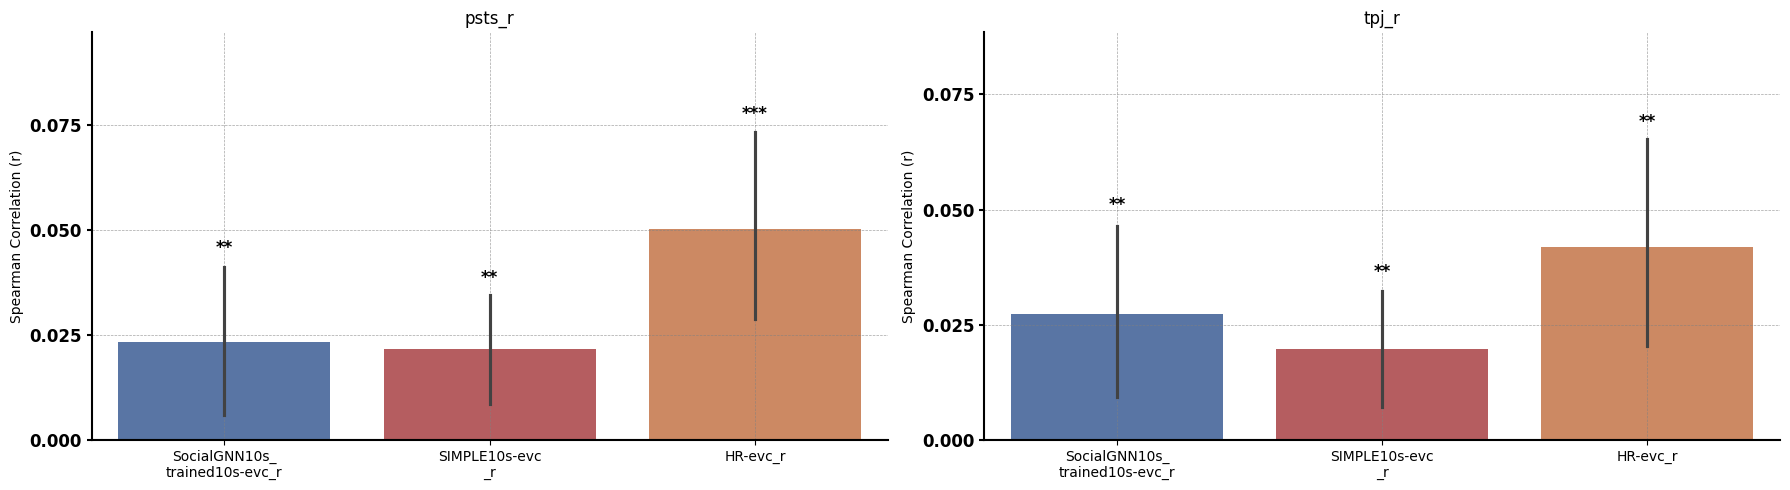

In [2]:
from standardRSA_analysis import load_features, get_feature_rdms, get_roiwise_neural_rdms
from roi_utils import make_roiwise_boxplot, signed_permutation_test_with_fdr
import pingouin as pg

models = ["SocialGNN10s_trained10s", "SIMPLE10s", "HR"]
control_roi = "evc_r"

features = load_features(models, sub_ids)
comparison_rdms = get_feature_rdms(features, sub_ids)

roi_names = [(None, "evc_r"), ("sipsts", "psts_r"), ("tom", "tpj_r")]
neural_rdms = get_roiwise_neural_rdms(sub_ids, roi_names, reliable_only=True)

fig, axs = plt.subplots(1, 2, figsize=(18, 5))

for ax, roi in zip(axs, ["psts_r", "tpj_r"]):
    sr_values = {sub: {} for sub in sub_ids}

    for sub in sub_ids:
        for model in models:
            data = pd.DataFrame({
                "X": neural_rdms[sub][roi],
                "Y1": comparison_rdms[model],
                "Y2": neural_rdms[sub][control_roi],
            })
            sr_values[sub][f"{model}-{control_roi}"] = pg.partial_corr(
                data=data, x="X", y="Y1", x_covar=["Y2"], method="spearman"
            )["r"].iloc[0]

    reorganized = {
        feature: [sr_values[sub][feature] for sub in sub_ids]
        for feature in next(iter(sr_values.values()))
    }
    _, p_fdr = signed_permutation_test_with_fdr(reorganized)

    make_roiwise_boxplot(
        sr_values, sub_ids, plot_title=roi, ax=ax,
        visualtype="bar", fdr_pvals=p_fdr
    )

plt.tight_layout()
plt.show()

# S4. Overlap between models and human behavior in explaining neural results & S5. Variance uniquely explained by human social ratings not captured by the models 

## ROI

In [4]:
from standardRSA_analysis import load_features, get_feature_rdms, get_roiwise_neural_rdms
from roi_utils import make_roiwise_boxplot, signed_permutation_test_with_fdr
import pingouin as pg

features2test = ['SocialGNN10s_trained10s', 'SIMPLE10s', 'HR', 'ME10s_reduced']
features = load_features(features2test, sub_ids)
comparison_rdms = get_feature_rdms(features, sub_ids)

roi_names = [('sipsts', 'psts_r'), ('tom', 'tpj_r')]
roiwise_neural_rdms = get_roiwise_neural_rdms(sub_ids, roi_names, reliable_only=True)
plot_style = "bar"


def run_roi_semipartial_plot(specs, fig_title):
    n = int(np.ceil(len(roi_names) / 2))
    fig, axs = plt.subplots(n, 2, figsize=(14, n * 5))
    axs = np.array(axs).ravel()

    for i, roi_name_tuple in enumerate(roi_names):
        roi_name = roi_name_tuple[1]
        sub_ids_rel = [s for s in sub_ids if s != "M23"] if roi_name in ["physics_pramod_l", "physics_pramod_r"] else sub_ids
        r_sr_values = {sub_id: {} for sub_id in sub_ids_rel}

        for sub_id in sub_ids_rel:
            neural_rdm = roiwise_neural_rdms[sub_id][roi_name]

            if np.isnan(neural_rdm).all():
                print(sub_id, roi_name, "Warning: ROI has only one voxel, returning NaN RDM.")
                for label in specs:
                    r_sr_values[sub_id][label] = np.nan
                continue

            for label, spec in specs.items():
                target, ycovars = spec['target'], spec['ycovars']
                data_dict = {'X': neural_rdm, 'Y': comparison_rdms[target]}
                ycovar_cols = [f'C{j}' for j in range(len(ycovars))]
                data_dict.update({col: comparison_rdms[covar] for col, covar in zip(ycovar_cols, ycovars)})
                data = pd.DataFrame(data_dict).dropna()

                if len(ycovar_cols) == 0:
                    r = pg.corr(data['X'], data['Y'], method='spearman')['r'].iloc[0]
                else:
                    r = pg.partial_corr(data=data, x='X', y='Y', y_covar=ycovar_cols, method='spearman')['r'].iloc[0]

                r_sr_values[sub_id][label] = r

        reorganized_r_sr = {feature: [r_sr_values[sub][feature] for sub in r_sr_values] for feature in next(iter(r_sr_values.values()))}
        p_uncorrected, p_fdr_corrected = signed_permutation_test_with_fdr(reorganized_r_sr)

        make_roiwise_boxplot(r_sr_values, sub_ids_rel, plot_title=roi_name, ax=axs[i], fdr_pvals=p_fdr_corrected, visualtype=plot_style)
        
        diff_sr = {}
        if fig_title.startswith("Model"):
            pairs = [('SocialGNN10s_trained10s', 'SocialGNN10s_trained10s-HR'), ('SIMPLE10s', 'SIMPLE10s-HR')]
        else:
            pairs = [('HR', f) for f in reorganized_r_sr if f != 'HR']
        for f1, f2 in pairs:
            r1 = np.array(reorganized_r_sr[f1])
            r2 = np.array(reorganized_r_sr[f2])
            mask = ~np.isnan(r1) & ~np.isnan(r2)
            diff_sr[(f1, f2)] = (r1 - r2)[mask]
        diff_p_uncorrected, diff_p_fdr_corrected = signed_permutation_test_with_fdr(diff_sr, two_tailed=True)

        # Report significant differences
        print(f"\n{roi_name}")
        for pair, p in diff_p_uncorrected.items():
            if p < 0.05:
                print(f"{pair}: {'***' if p < 0.001 else '**' if p < 0.01 else '*' }")
            else:
                print(f"{pair}: {p}")

    for j in range(i + 1, len(axs)):
        axs[j].axis("off")

    fig.suptitle(fig_title, y=1.02)
    plt.tight_layout()
    return fig

M03: Loaded saved ROIs
M04: Loaded saved ROIs
M05: Loaded saved ROIs
M06: Loaded saved ROIs
M08: Loaded saved ROIs
M09: Loaded saved ROIs
M10: Loaded saved ROIs
M11: Loaded saved ROIs
M12: Loaded saved ROIs
M13: Loaded saved ROIs
M15: Loaded saved ROIs
M17: Loaded saved ROIs
M18: Loaded saved ROIs
M19: Loaded saved ROIs
M20: Loaded saved ROIs
M21: Loaded saved ROIs
M22: Loaded saved ROIs
M23: Loaded saved ROIs
M24: Loaded saved ROIs
M25: Loaded saved ROIs
M26: Loaded saved ROIs
M27: Loaded saved ROIs
M28: Loaded saved ROIs
M29: Loaded saved ROIs
M30: Loaded saved ROIs



psts_r
('SocialGNN10s_trained10s', 'SocialGNN10s_trained10s-HR'): ***
('SIMPLE10s', 'SIMPLE10s-HR'): ***

tpj_r
('SocialGNN10s_trained10s', 'SocialGNN10s_trained10s-HR'): ***
('SIMPLE10s', 'SIMPLE10s-HR'): ***


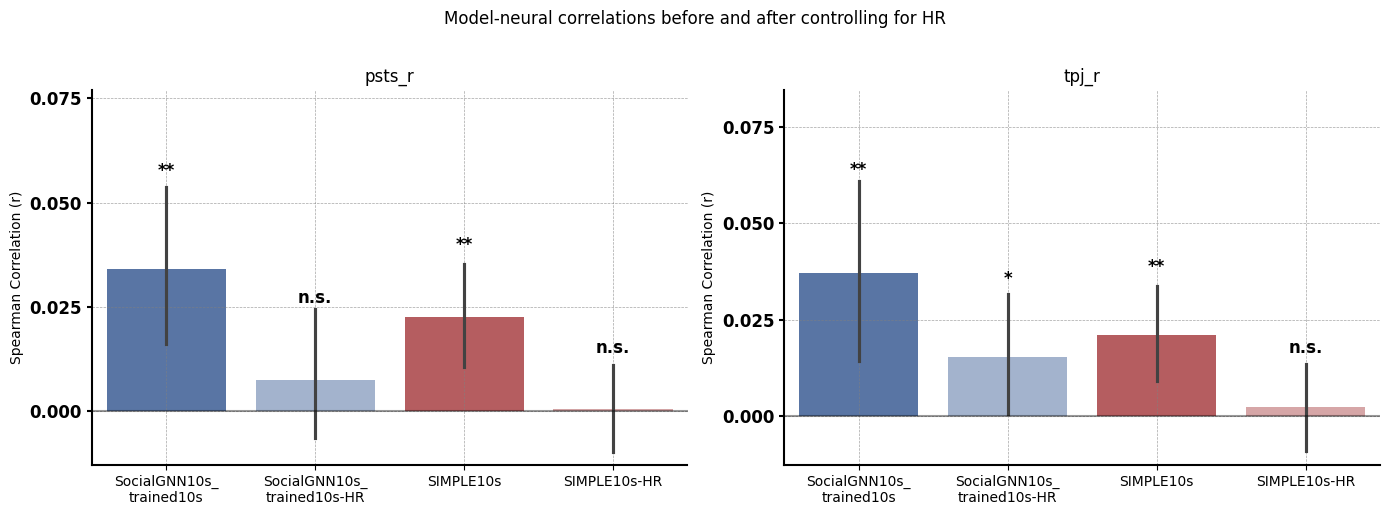

In [5]:
s4_specs = {
    "SocialGNN10s_trained10s": {'target': 'SocialGNN10s_trained10s', 'ycovars': []},
    "SocialGNN10s_trained10s-HR": {'target': 'SocialGNN10s_trained10s', 'ycovars': ['HR']},
    "SIMPLE10s": {'target': 'SIMPLE10s', 'ycovars': []},
    "SIMPLE10s-HR": {'target': 'SIMPLE10s', 'ycovars': ['HR']},
}

fig_s4 = run_roi_semipartial_plot(s4_specs, "Model-neural correlations before and after controlling for HR")


psts_r
('HR', 'HR-SocialGNN10s_trained10s'): *
('HR', 'HR-SIMPLE10s'): 0.060187962407518496
('HR', 'HR-SocialGNN10s_trained10s+SIMPLE10s'): *
('HR', 'HR-SocialGNN10s_trained10s+SIMPLE10s+ME10s_reduced'): *

tpj_r
('HR', 'HR-SocialGNN10s_trained10s'): **
('HR', 'HR-SIMPLE10s'): 0.054989002199560086
('HR', 'HR-SocialGNN10s_trained10s+SIMPLE10s'): **
('HR', 'HR-SocialGNN10s_trained10s+SIMPLE10s+ME10s_reduced'): **


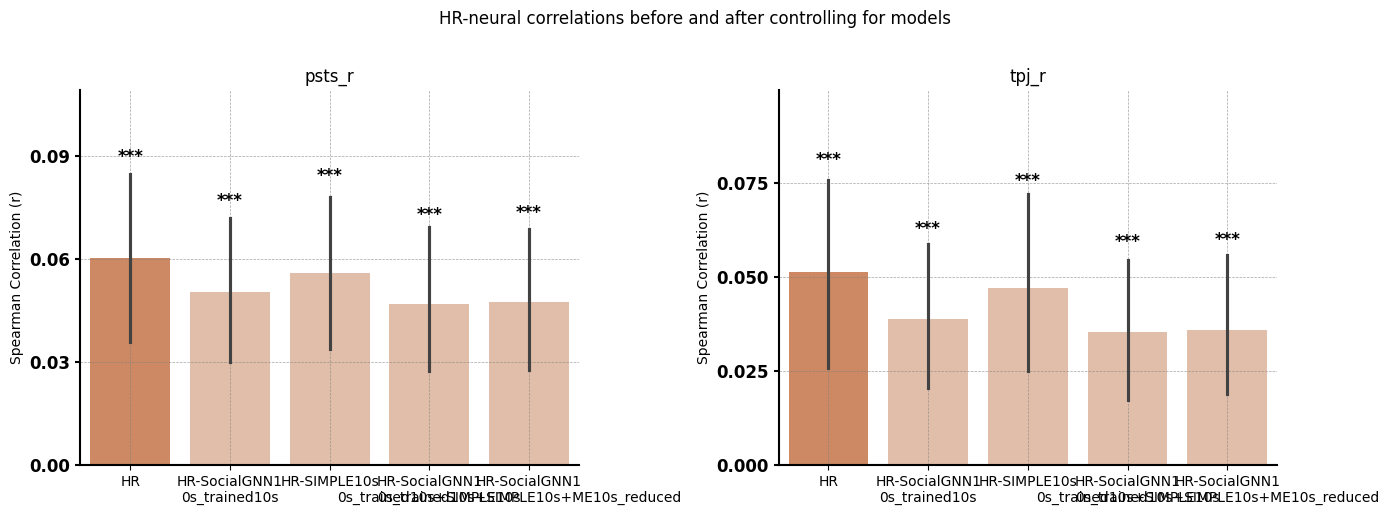

In [6]:
s5_specs = {
    "HR": {'target': 'HR', 'ycovars': []},
    "HR-SocialGNN10s_trained10s": {'target': 'HR', 'ycovars': ['SocialGNN10s_trained10s']},
    "HR-SIMPLE10s": {'target': 'HR', 'ycovars': ['SIMPLE10s']},
    "HR-SocialGNN10s_trained10s+SIMPLE10s": {'target': 'HR', 'ycovars': ['SocialGNN10s_trained10s', 'SIMPLE10s']},
    "HR-SocialGNN10s_trained10s+SIMPLE10s+ME10s_reduced": {'target': 'HR', 'ycovars': ['SocialGNN10s_trained10s', 'SIMPLE10s', 'ME10s_reduced']},
}

fig_s5 = run_roi_semipartial_plot(s5_specs, "HR-neural correlations before and after controlling for models")

## Whole-brain

## S5

In [7]:
from standardRSA_analysis import get_wholebrain_neural_data, load_features, get_feature_rdms
from searchlight_utils import process_voxel_multi_semipartial
from tqdm import tqdm
import multiprocessing as mp

def run_searchlight_multi_semipartial(fmri_img, mask_img, radius, target_rdm, covar_rdms, n_proc=8):
    indices = list(itertools.product(range(fmri_img.shape[0]), range(fmri_img.shape[1]), range(fmri_img.shape[2])))
    args = [(x, y, z, fmri_img, mask_img, radius, target_rdm, covar_rdms) for x, y, z in indices]

    with mp.get_context("fork").Pool(processes=n_proc) as pool:
        results = pool.map(process_voxel_multi_semipartial, args)

    return results

features2test = ['SocialGNN10s_trained10s', 'SIMPLE10s', 'HR', 'ME10s_reduced']
features = load_features(features2test, sub_ids)
comparison_rdms = get_feature_rdms(features, sub_ids)

radius = 3
beta_images, mask_images = get_wholebrain_neural_data(sub_ids, within_reliable=True)
reliable_suffix = '_withinreliablevoxels'

multi_comparisons = {
    'HRSocialGNN10s_trained10sSIMPLE10sME10s_reduced': ('HR', ['SocialGNN10s_trained10s', 'SIMPLE10s', 'ME10s_reduced'])
}

for label, (target, covars) in multi_comparisons.items():
    for sub_id in tqdm(sub_ids, desc=label):
        target_vec = comparison_rdms[target][sub_id] if isinstance(comparison_rdms[target], dict) else comparison_rdms[target]
        covar_vecs = [comparison_rdms[c][sub_id] if isinstance(comparison_rdms[c], dict) else comparison_rdms[c] for c in covars]

        fmri_img = beta_images[sub_id]
        mask_img = mask_images[sub_id]

        results = run_searchlight_multi_semipartial(fmri_img, mask_img, radius, target_vec, covar_vecs)

        r_map = np.full(fmri_img.shape[:3], np.nan)
        for x, y, z, r in results:
            r_map[x, y, z] = r

        output_dir = f'../derivatives/analyses/rsa/sub-{sub_id}/'
        os.makedirs(output_dir, exist_ok=True)

        outfile = output_dir + f'sub-{sub_id}_searchlightRSA-{label}_radius-{radius}_stat-srmap{reliable_suffix}.nii.gz'
        nib.save(nib.Nifti1Image(r_map, affine=mask_img.affine), outfile)

HRSocialGNN10s_trained10sSIMPLE10sME10s_reduced: 100%|█████████████████| 25/25 [15:13<00:00, 36.52s/it]


100%|███████████████████████████████████████████████████████████████████| 1/1 [02:27<00:00, 147.92s/it]


Making projectedsurf plots


  0%|                                                                            | 0/1 [00:00<?, ?it/s]

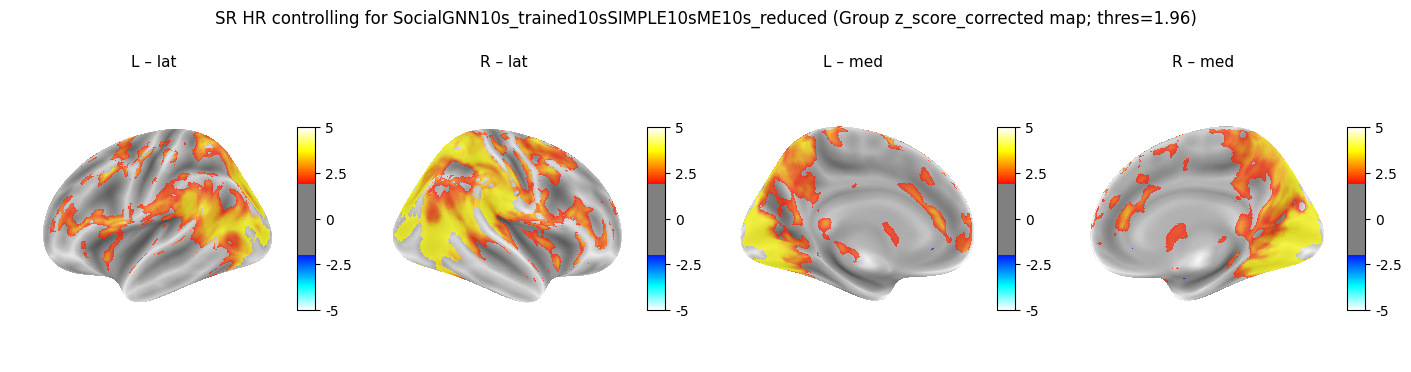

100%|████████████████████████████████████████████████████████████████████| 1/1 [01:39<00:00, 99.15s/it]


In [8]:
# Plot

from general_utils import plot_on_surf, get_grouped_wholebrainmap, plot_on_surf_z

plot_styles = [ "projectedsurf"]

sr_group_maps = {}

for feature1, feature2 in tqdm(multi_comparisons.values()):
    feature2="".join(feature2)
    images12 = []  # variance uniquely explained by feature1 (controlling for feature2)

    for sub_id in sub_ids:
        output_dir = f'../derivatives/analyses/rsa/sub-{sub_id}/'
        sr1_img = output_dir + f'sub-{sub_id}_searchlightRSA-{feature1}{feature2}_radius-{radius}_stat-srmap{reliable_suffix}.nii.gz'
        images12.append(sr1_img)

    sr_group_maps[(feature1, feature2)] = get_grouped_wholebrainmap(images12, nonparametric=True, correction='fdr')
    

import matplotlib.pyplot as plt
thres = 1.96
out_type = "z_score_corrected"
plot_dir = f'../derivatives/analyses/plots/rsa/group/'
subj_group = "M"


for plot_style in plot_styles:
    print(f"Making {plot_style} plots")
    plot_style_suffix = "_projectedsurf" if plot_style == "projectedsurf" else ""
    vmax = 5 if plot_style == "projectedsurf" else 5.5
       
    for f1, f2 in tqdm(multi_comparisons.values()):
        f2="".join(f2)
        if plot_style == "projectedsurf":
            fig, _ = plot_on_surf_z(sr_group_maps[(f1, f2)][out_type], thres=thres,vmax_inp=vmax)
        else:
            fig, _ = plot_on_surf(sr_group_maps[(f1, f2)][out_type],thres=thres,vmax_inp=vmax)
        fig.suptitle(f"SR {f1} controlling for {f2} (Group {out_type} map; thres=1.96)")
        fig.savefig(plot_dir + f'standardrsa_uniqvar_{subj_group}groupmap_{f1}controlling{f2}{reliable_suffix}_{out_type}_{thres}{plot_style_suffix}.png', bbox_inches='tight', dpi=600)
        plt.show()
        plt.close(fig)

# S7. Alternate representations from SocialGNN 

# S8. Alternate representations from SIMPLE 

# S9. Effect of removing overlapping voxels between pSTS (r) and TPJ (r) 

In [9]:
### Load ROIs and create non-overlapping versions

In [10]:
from standardRSA_analysis import load_features, get_feature_rdms, load_conditionwise_betas
from general_utils import get_rdm
from createROIs import SubjROIs
import nibabel as nib
import numpy as np
import pandas as pd

sub_ids = ["M03", "M04", "M05", "M06", "M08", "M09", "M10", "M11", "M12", "M13", "M15", "M17", "M18", "M19", "M20","M21", "M22", "M23", "M24", "M25","M26", "M27", "M28", "M29", "M30"]
features2test = ['SocialGNN10s_trained10s', 'SIMPLE10s', 'HR', 'ME10s_reduced', 'VisualRNN10s']
within_reliable = True
roi_names = [('sipsts', 'psts_r'), ('tom', 'tpj_r')]

features = load_features(features2test, sub_ids)
comparison_rdms = get_feature_rdms(features, sub_ids)

""" Extract neural RDMs for ROIs, optionally within reliable voxels """
betas_4d_dict, valid_voxels_mask = load_conditionwise_betas(sub_ids)

roiwise_neural_rdms = {}
roi_sizes = {}
for sub_id in sub_ids:
    ref_img = nib.load(f'../derivatives/fmriprep/sub-{sub_id}/func/sub-{sub_id}_task-main_run-1_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz')
    condition_imgs = nib.Nifti1Image(betas_4d_dict[sub_id], affine=ref_img.affine)

    roi_names_subj = [r for r in roi_names if not (sub_id == "M23" and r[0] == "physics")]
    subj = SubjROIs(sub_id, roi_names_subj)
    if within_reliable:
        subj.generate_reliable_rois()
        roi_masks = subj.reliable_rois
    else:
        roi_masks = subj.subjROIs
    
    psts = roi_masks['sipsts']['psts_r']
    tpj = roi_masks['tom']['tpj_r']
    psts_notpj = psts.get_fdata().astype(bool) & (~tpj.get_fdata().astype(bool))
    tpj_nopsts = tpj.get_fdata().astype(bool) & (~psts.get_fdata().astype(bool))
    
    roi_masks['sipsts']['psts_r_notpjr'] = nib.Nifti1Image(psts_notpj.astype(int), psts.affine, psts.header)
    roi_masks['tom']['tpj_r_nopstsr'] = nib.Nifti1Image(tpj_nopsts.astype(int), tpj.affine, tpj.header)
    roi_names_subj.extend([('sipsts', 'psts_r_notpjr'), ('tom', 'tpj_r_nopstsr')])

    roi_reprs = subj.get_roi_representation(condition_imgs, valid_voxel_mask=valid_voxels_mask[sub_id],roi_masks=roi_masks)

    # Generate RDM for the ROI and store it in the dictionary
    roiwise_neural_rdms[sub_id] = {roi_name[1]: np.array(get_rdm(roi_reprs[roi_name[1]].T)) for roi_name in roi_names_subj}
    
    # Get effective roi sizes (ROI ∩ valid_voxels_mask)
    roi_sizes[sub_id] = {}
    valid_bool = valid_voxels_mask[sub_id]  # already boolean

    for task in roi_masks.keys():
        for roi_name, mask_img in roi_masks[task].items():
            roi_bool = mask_img.get_fdata().astype(bool)
            roi_sizes[sub_id][roi_name] = np.count_nonzero(roi_bool & valid_bool)

M03: Loaded saved ROIs
M04: Loaded saved ROIs
M05: Loaded saved ROIs
M06: Loaded saved ROIs
M08: Loaded saved ROIs
M09: Loaded saved ROIs
M10: Loaded saved ROIs
M11: Loaded saved ROIs
M12: Loaded saved ROIs
M13: Loaded saved ROIs
M15: Loaded saved ROIs
M17: Loaded saved ROIs
M18: Loaded saved ROIs
M19: Loaded saved ROIs
M20: Loaded saved ROIs
M21: Loaded saved ROIs
M22: Loaded saved ROIs
M23: Loaded saved ROIs
M24: Loaded saved ROIs
M25: Loaded saved ROIs
M26: Loaded saved ROIs
M27: Loaded saved ROIs
M28: Loaded saved ROIs
M29: Loaded saved ROIs
M30: Loaded saved ROIs


In [11]:
### ROI sizes

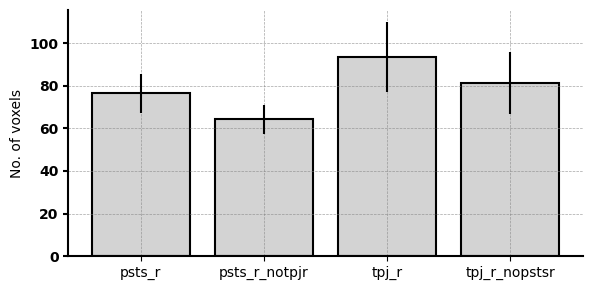

In [12]:
import matplotlib.pyplot as plt
# --- Compute mean and 95% CI for each column ---
df = pd.DataFrame.from_dict(roi_sizes, orient='index')[['psts_r', 'psts_r_notpjr', 'tpj_r', 'tpj_r_nopstsr']]
means = df.mean()
sems = df.sem()
cis = 1.96 * sems  # 95% CI assuming normality

# --- Plot ---
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(means.index, means.values, yerr=cis.values, edgecolor='black', linewidth=1.5, color='lightgray', alpha = 1)
ax.set_ylabel('No. of voxels')
plt.tight_layout()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Bold y-axis tick labels
ax.tick_params(axis='y', labelsize=10, width=1.5)
for tick in ax.get_yticklabels():
    tick.set_fontweight('semibold')

plt.show()

In [13]:
from roi_utils import ROI_RSA_roiwise, ROI_RSAuniqvar_roiwise
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

def make_roiwise_boxplot_grouped(r_values_1, r_values_2, sub_ids, group_labels=('Condition 1', 'Condition 2'), plot_title=None,
    ax=None, ylabel='Spearman Correlation (r)', add_noiseceiling=None, fdr_pvals=None, diff_fdr_pvals=None):
    """
    Grouped bar plot (seaborn) where each model (x-axis) has two bars:
    one for r_values_1, one for r_values_2.
    r_values_*: dict[sub_id][model] -> value
    """

    if ax is None:
        fig = plt.figure(figsize=(6, 4))
        ax = plt.gca()

    # ------------ Data prep ------------
    df1 = pd.DataFrame(r_values_1).T   # subjects x models
    df2 = pd.DataFrame(r_values_2).T
    df1 = df1.fillna(np.nan)
    df2 = df2.fillna(np.nan)

    models = list(df1.columns)              # Comparison RDM levels (x)
    conditions = list(group_labels)         # hue levels

    # Long format for seaborn
    melt1 = df1.reset_index().melt(
        id_vars='index', var_name='Comparison RDM', value_name='r'
    )
    melt2 = df2.reset_index().melt(
        id_vars='index', var_name='Comparison RDM', value_name='r'
    )
    melt1['Condition'] = conditions[0]
    melt2['Condition'] = conditions[1]
    r_values_melted = pd.concat([melt1, melt2], ignore_index=True)

    # ------------ Base colors per model ------------
    model2colors = {
        'SocialGNN10s_trained10s': (0.2980392156862745, 0.4470588235294118, 0.6901960784313725), #blue
        'SIMPLE10s': (0.7686274509803922, 0.3058823529411765, 0.3215686274509804), #red
        'HR': (0.8666666666666667, 0.5176470588235295, 0.3215686274509804), #orange
        'VisualRNN10s': (0.3333333333333333, 0.6588235294117647, 0.40784313725490196), #green
        'ME10s_reduced': (0.5058823529411764, 0.4470588235294118, 0.7019607843137254), 
        'SocialGNN10s_trained10s-SIMPLE10s': (0.2980392156862745, 0.4470588235294118, 0.6901960784313725), 
        'SIMPLE10s-SocialGNN10s_trained10s': (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
    }


    # ------------ Plot with seaborn ------------
    sns.barplot(x='Comparison RDM', y='r', hue='Condition', data=r_values_melted, estimator=np.mean, errorbar=('ci', 95), ax=ax,
        order=models, hue_order=conditions, edgecolor='black', linewidth=1.5)

    # --- Apply colors + hatching for "Condition 2" ---
    n_x = len(models)
    n_h = len(conditions)
    patches = ax.patches[:n_x * n_h]  # one bar per condition × model

    for i, patch in enumerate(patches):
        h_idx = i // n_x    # hue (condition)
        x_idx = i % n_x     # model
        model = models[x_idx]
        cond  = conditions[h_idx]

        base = model2colors.get(model, (0.5, 0.5, 0.5))
        patch.set_facecolor(base)
        patch.set_edgecolor('black')

        # add diagonal stripes for the second condition
        if cond == conditions[1]:
            patch.set_hatch('\\')
            patch.set_alpha(0.9)

    # ------------ Noise ceiling (optional) ------------
    if add_noiseceiling is not None and plot_title is not None:
        reliability_per_roi = [(2 * add_noiseceiling[sub_id][plot_title]) /(1 + add_noiseceiling[sub_id][plot_title])
            for sub_id in sub_ids]
        mean_nc = np.nanmean(reliability_per_roi)
        ax.axhline(mean_nc, color='darkgray', linestyle='-.', linewidth=2, alpha=0.6,label='Split-Half RSA (mean)',)

    # ------------ Formatting ------------
    sns.despine(ax=ax, top=True, right=True)

    ax.set_title(plot_title)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)

    ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    ax.axhline(0, color='black', linewidth=1.5, linestyle='-', alpha=0.4)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

    ax.tick_params(axis='y', labelsize=10, width=1.5)
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')

    # Optional: split long labels into two lines
    new_labels = [
        m[:13] + "\n" + m[13:] if len(m) > 13 else m
        for m in models
    ]
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(new_labels, rotation=0)

    plt.tight_layout()
    ax.legend_.remove()

    return ax


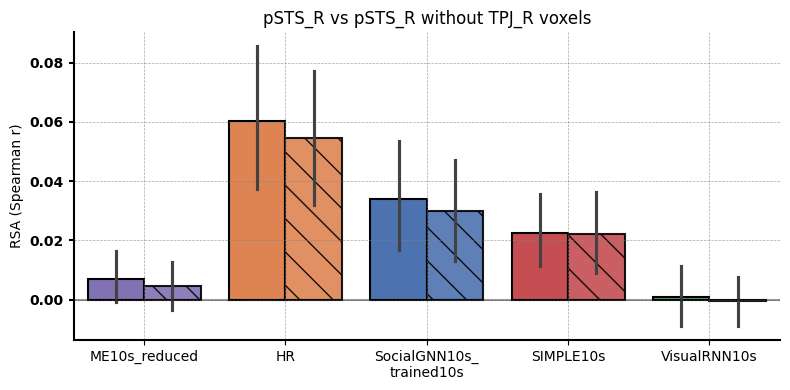

{'ME10s_reduced': 0.08223355328934212, 'HR': 0.0009998000399920016, 'SocialGNN10s_trained10s': 0.002499500099980004, 'SIMPLE10s': 0.002666133439978671, 'VisualRNN10s': 0.4523095380923815}
{'ME10s_reduced': 0.15946810637872422, 'HR': 0.0009998000399920016, 'SocialGNN10s_trained10s': 0.0023328667599813373, 'SIMPLE10s': 0.0023328667599813373, 'VisualRNN10s': 0.5444911017796441}


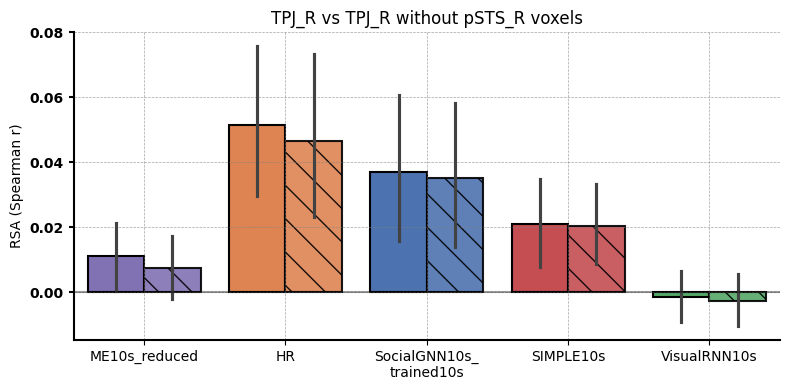

{'ME10s_reduced': 0.03624275144971006, 'HR': 0.002499500099980004, 'SocialGNN10s_trained10s': 0.002499500099980004, 'SIMPLE10s': 0.006332066919949343, 'VisualRNN10s': 0.641871625674865}
{'ME10s_reduced': 0.10697860427914417, 'HR': 0.003999200159968006, 'SocialGNN10s_trained10s': 0.004999000199960009, 'SIMPLE10s': 0.004999000199960008, 'VisualRNN10s': 0.7280543891221756}


In [14]:
from roi_utils import signed_permutation_test_with_fdr

r_psts, _     = ROI_RSA_roiwise('psts_r', sub_ids, roiwise_neural_rdms, comparison_rdms)
r_psts_ex, _  = ROI_RSA_roiwise('psts_r_notpjr', sub_ids, roiwise_neural_rdms, comparison_rdms)

fig, ax = plt.subplots(figsize=(8, 4))
make_roiwise_boxplot_grouped(
    r_values_1=r_psts,
    r_values_2=r_psts_ex,
    sub_ids=sub_ids,
    group_labels=('pSTS_R', 'pSTS_R (no TPJ_R)'),
    plot_title='pSTS_R vs pSTS_R without TPJ_R voxels',
    ylabel='RSA (Spearman r)',
    ax=ax
)
plt.show()

reorganized_r = {feature: [r_psts[sub][feature] for sub in r_psts] for feature in next(iter(r_psts.values()))}
p_uncorrected, p_fdr_corrected = signed_permutation_test_with_fdr(reorganized_r)
print(p_fdr_corrected)
reorganized_r = {feature: [r_psts_ex[sub][feature] for sub in r_psts_ex] for feature in next(iter(r_psts_ex.values()))}
p_uncorrected, p_fdr_corrected = signed_permutation_test_with_fdr(reorganized_r)
print(p_fdr_corrected)


r_tpj, _     = ROI_RSA_roiwise('tpj_r', sub_ids, roiwise_neural_rdms, comparison_rdms)
r_tpj_ex, _  = ROI_RSA_roiwise('tpj_r_nopstsr', sub_ids, roiwise_neural_rdms, comparison_rdms)

fig, ax = plt.subplots(figsize=(8, 4))
make_roiwise_boxplot_grouped(
    r_values_1=r_tpj,
    r_values_2=r_tpj_ex,
    sub_ids=sub_ids,
    group_labels=('tpj_R', 'tpj_R (no psts_R)'),
    plot_title='TPJ_R vs TPJ_R without pSTS_R voxels',
    ylabel='RSA (Spearman r)',
    ax=ax
)
plt.show()

reorganized_r = {feature: [r_tpj[sub][feature] for sub in r_tpj] for feature in next(iter(r_tpj.values()))}
p_uncorrected, p_fdr_corrected = signed_permutation_test_with_fdr(reorganized_r)
print(p_fdr_corrected)
reorganized_r = {feature: [r_tpj_ex[sub][feature] for sub in r_tpj_ex] for feature in next(iter(r_tpj_ex.values()))}
p_uncorrected, p_fdr_corrected = signed_permutation_test_with_fdr(reorganized_r)
print(p_fdr_corrected)

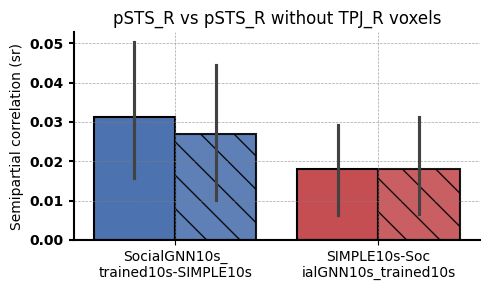

{'SocialGNN10s_trained10s-SIMPLE10s': 0.0011997600479904018, 'SIMPLE10s-SocialGNN10s_trained10s': 0.0023995200959808036}
{'SocialGNN10s_trained10s-SIMPLE10s': 0.004399120175964807, 'SIMPLE10s-SocialGNN10s_trained10s': 0.004799040191961607}


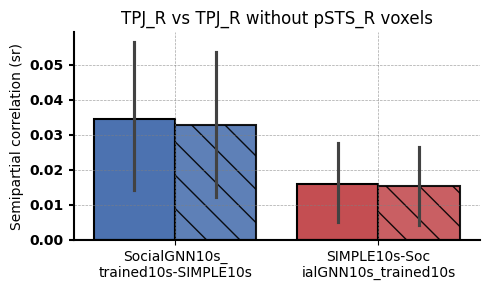

{'SocialGNN10s_trained10s-SIMPLE10s': 0.0027994401119776045, 'SIMPLE10s-SocialGNN10s_trained10s': 0.0065986802639472104}
{'SocialGNN10s_trained10s-SIMPLE10s': 0.004399120175964807, 'SIMPLE10s-SocialGNN10s_trained10s': 0.010397920415916816}


In [15]:
sr_comparisons_rdms = {
        pair: (comparison_rdms[pair[0]], comparison_rdms[pair[1]])
        for pair in [('SocialGNN10s_trained10s', 'SIMPLE10s')]
    }

sr_psts    = ROI_RSAuniqvar_roiwise('psts_r', sub_ids, roiwise_neural_rdms, sr_comparisons_rdms)
sr_psts_ex  = ROI_RSAuniqvar_roiwise('psts_r_notpjr', sub_ids, roiwise_neural_rdms, sr_comparisons_rdms)

fig, ax = plt.subplots(figsize=(5, 3))
make_roiwise_boxplot_grouped(
    r_values_1=sr_psts,
    r_values_2=sr_psts_ex,
    sub_ids=sub_ids,
    group_labels=('pSTS_R', 'pSTS_R (no TPJ_R)'),
    plot_title='pSTS_R vs pSTS_R without TPJ_R voxels',
    ylabel='Semipartial correlation (sr)',
    ax=ax
)
plt.show()

reorganized_sr = {feature: [sr_psts[sub][feature] for sub in sr_psts] for feature in next(iter(sr_psts.values()))}
p_uncorrected, p_fdr_corrected = signed_permutation_test_with_fdr(reorganized_sr)
print(p_fdr_corrected)
reorganized_sr = {feature: [sr_psts_ex[sub][feature] for sub in sr_psts_ex] for feature in next(iter(sr_psts_ex.values()))}
p_uncorrected, p_fdr_corrected = signed_permutation_test_with_fdr(reorganized_sr)
print(p_fdr_corrected)

sr_tpj     = ROI_RSAuniqvar_roiwise('tpj_r', sub_ids, roiwise_neural_rdms, sr_comparisons_rdms)
sr_tpj_ex  = ROI_RSAuniqvar_roiwise('tpj_r_nopstsr', sub_ids, roiwise_neural_rdms, sr_comparisons_rdms)

fig, ax = plt.subplots(figsize=(5, 3))
make_roiwise_boxplot_grouped(
    r_values_1=sr_tpj,
    r_values_2=sr_tpj_ex,
    sub_ids=sub_ids,
    group_labels=('tpj_R', 'tpj_R (no psts_R)'),
    plot_title='TPJ_R vs TPJ_R without pSTS_R voxels',
    ylabel='Semipartial correlation (sr)',
    ax=ax
)
plt.show()


reorganized_sr = {feature: [sr_tpj[sub][feature] for sub in sr_tpj] for feature in next(iter(sr_tpj.values()))}
p_uncorrected, p_fdr_corrected = signed_permutation_test_with_fdr(reorganized_sr)
print(p_fdr_corrected)
reorganized_sr = {feature: [sr_tpj_ex[sub][feature] for sub in sr_tpj_ex] for feature in next(iter(sr_tpj_ex.values()))}
p_uncorrected, p_fdr_corrected = signed_permutation_test_with_fdr(reorganized_sr)
print(p_fdr_corrected)

# S10. Plot Parcels and ROIs

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from nilearn import datasets, surface, plotting
from createROIs import ROI, SubjROIs


def surf_atlas(sub_id="M06", source="parcels", names=None,space="MNI152NLin2009cAsym", mesh="fsaverage5", overwrite="last"):
    fs = datasets.fetch_surf_fsaverage(mesh=mesh)
    atlasL = atlasR = None

    if source == "subj_rois":
        subj = SubjROIs(sub_id, names)
        subj.generate_reliable_rois()
        flat = {roi: img for _, d in subj.reliable_rois.items() for roi, img in d.items()}
        names = tuple(names)
        get = lambda n: (flat[n]["l"], flat[n]["r"]) if isinstance(flat[n], dict) else (flat[n], flat[n])
    else:
        names = tuple(names)
        def get(n):
            p = ROI(sub_id=sub_id, parcel_name=n, task="sipsts", top_perc=10, space=space).parcel
            return (p["l"], p["r"]) if isinstance(p, dict) else (p, p)

    for i, n in enumerate(names, 1):
        imgL, imgR = get(n)
        texL = surface.vol_to_surf(imgL, fs.pial_left,  interpolation="nearest")
        texR = surface.vol_to_surf(imgR, fs.pial_right, interpolation="nearest")
        if atlasL is None:
            atlasL = np.zeros_like(texL, dtype=np.int32)
            atlasR = np.zeros_like(texR, dtype=np.int32)
        if overwrite == "first":
            atlasL[(atlasL == 0) & (texL > 0)] = i
            atlasR[(atlasR == 0) & (texR > 0)] = i
        else:
            atlasL[texL > 0] = i
            atlasR[texR > 0] = i

    return fs, atlasL, atlasR, names


def plot_surf_atlas(fs, atlasL, atlasR, names, out="our_parcels.png", title="Parcels"):
    tab20 = plt.get_cmap("tab20")
    roi_colors = {
        "tpj": tab20(6), "asts": tab20(19), "psts": tab20(0), "mt": tab20(4),
        "evc": tab20(8), "mmpfc": tab20(7), "dmpfc": tab20(12), "vmpfc": tab20(10),
    }
    cmap = ListedColormap([(0, 0, 0, 0)] + [roi_colors.get(n[:-2] if n.endswith(("_l","_r")) else n, tab20(18)) for n in names])

    fig, ax = plt.subplots(2, 2, figsize=(8, 6), subplot_kw={"projection": "3d"}, constrained_layout=True)
    panels = [(0,0,"left","lateral"), (0,1,"right","lateral"), (1,0,"left","medial"), (1,1,"right","medial")]
    for r, c, hemi, view in panels:
        plotting.plot_surf_roi(
            fs.infl_left if hemi == "left" else fs.infl_right,
            atlasL if hemi == "left" else atlasR,
            hemi=hemi, view=view,
            bg_map=fs.sulc_left if hemi == "left" else fs.sulc_right,
            bg_on_data=True, cmap=cmap, axes=ax[r, c], title=f"{hemi} — {view}",
        )

    handles = [mpatches.Patch(color=cmap(i+1), label=names[i]) for i in range(len(names))]
    fig.legend(handles=handles, bbox_to_anchor=(1.02, 0.5), loc="center left",
               frameon=False, title=title)

    #fig.savefig(out, dpi=600, bbox_inches="tight")
    plt.show()


/Users/mmalik16/opt/anaconda3/envs/fMRI_analysis/lib/python3.11/site-packages/nilearn/_utils/niimg_conversions.py:326: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  niimg = new_img_like(niimg, data, niimg.affine)
/Users/mmalik16/opt/anaconda3/envs/fMRI_analysis/lib/python3.11/site-packages/nilearn/_utils/niimg_conversions.py:326: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  niimg = new_img_like(niimg, data, niimg.affine)


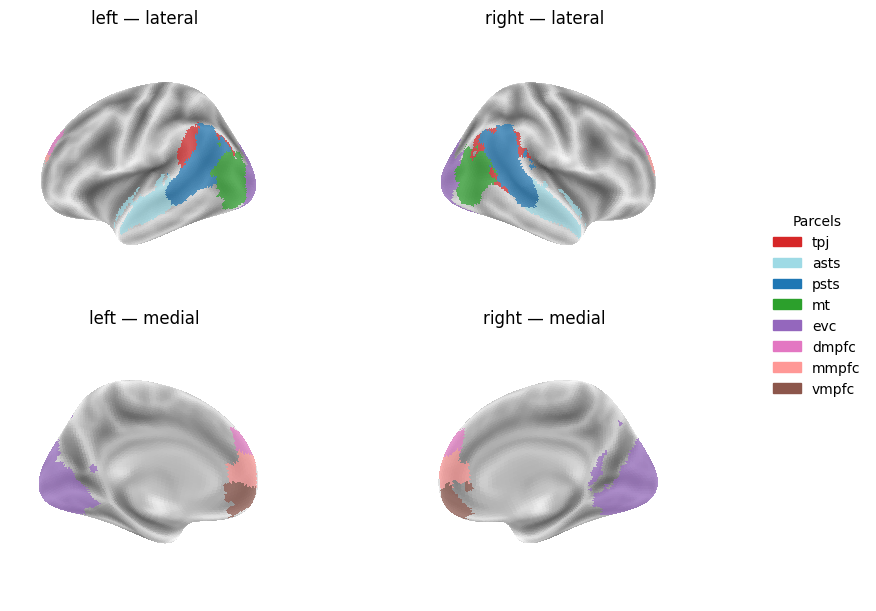

In [17]:
# parcels
parcel_names = ("tpj","asts","psts","mt","evc","dmpfc","mmpfc","vmpfc")
fs, aL, aR, nm = surf_atlas(sub_id="M06", source="parcels", names=parcel_names)
plot_surf_atlas(fs, aL, aR, nm, out="our_parcels.png", title="Parcels")

M03: Loaded saved ROIs


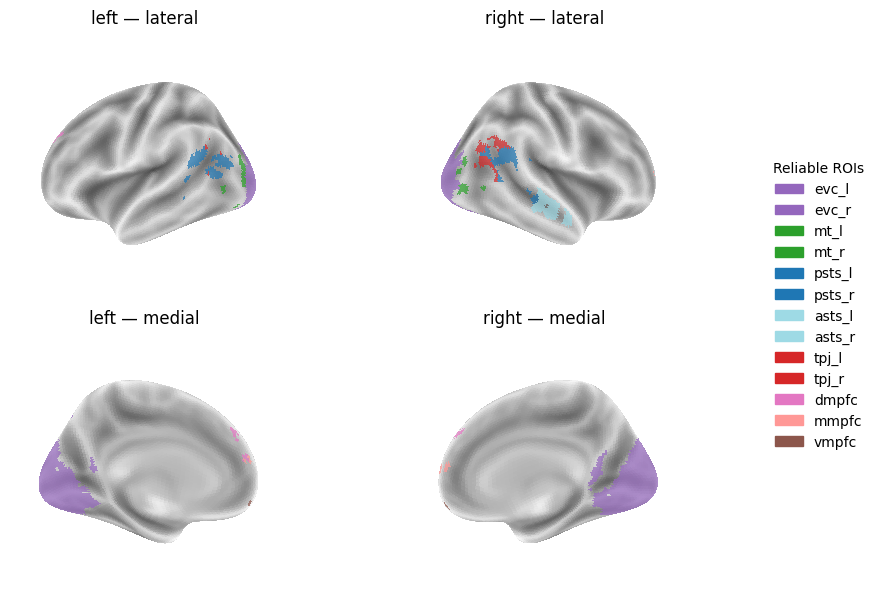

M04: Loaded saved ROIs


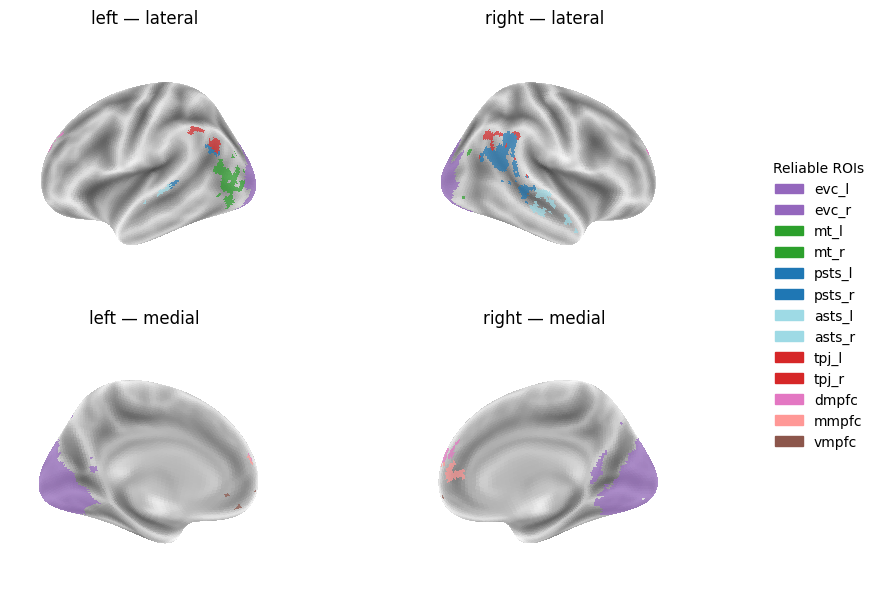

M05: Loaded saved ROIs


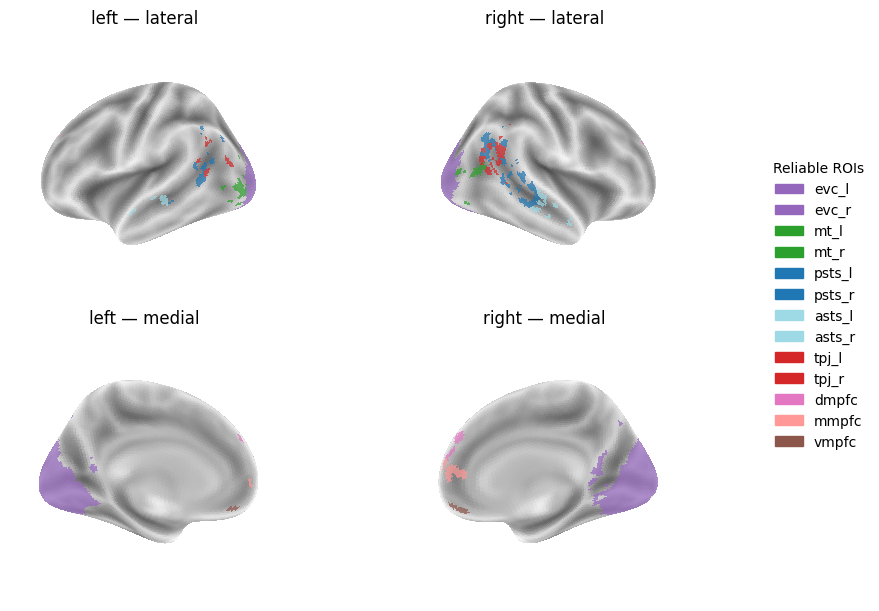

M06: Loaded saved ROIs


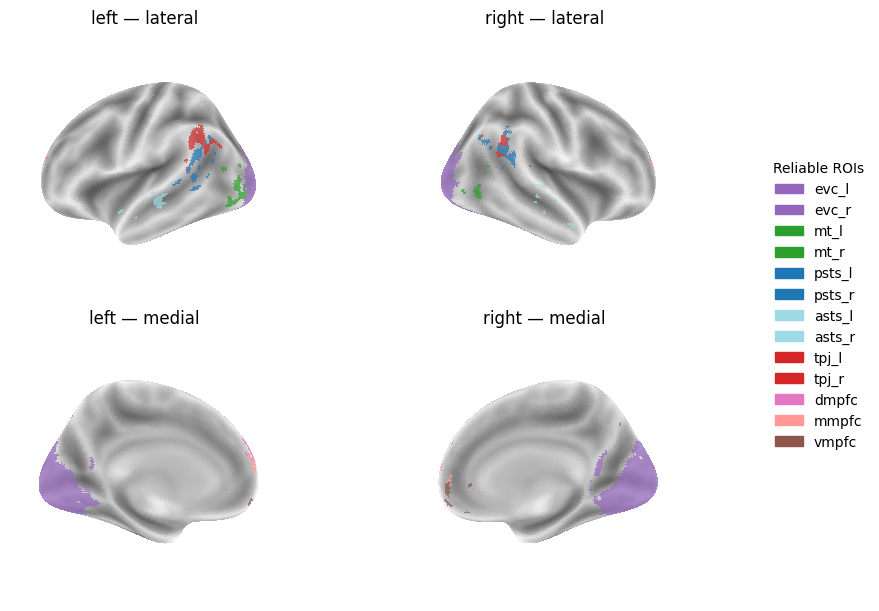

M08: Loaded saved ROIs


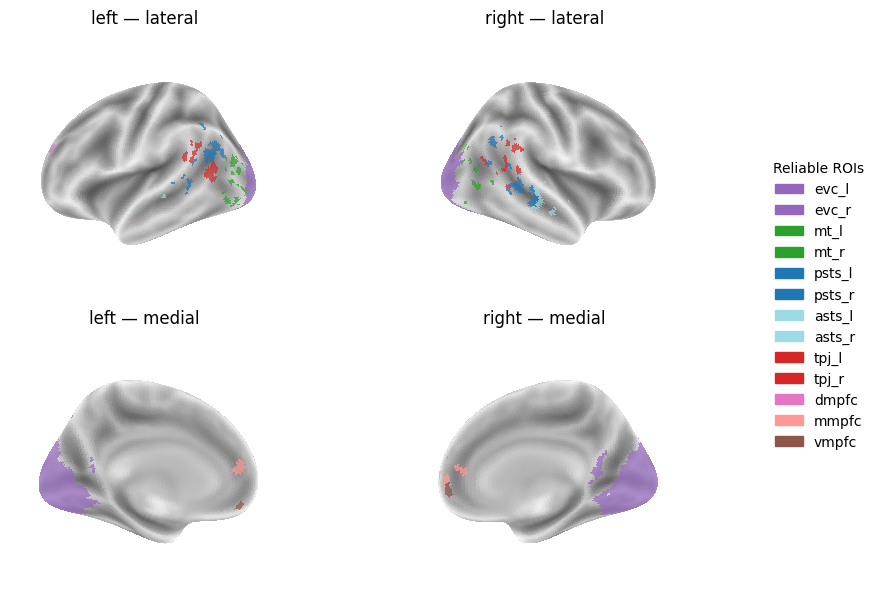

M09: Loaded saved ROIs


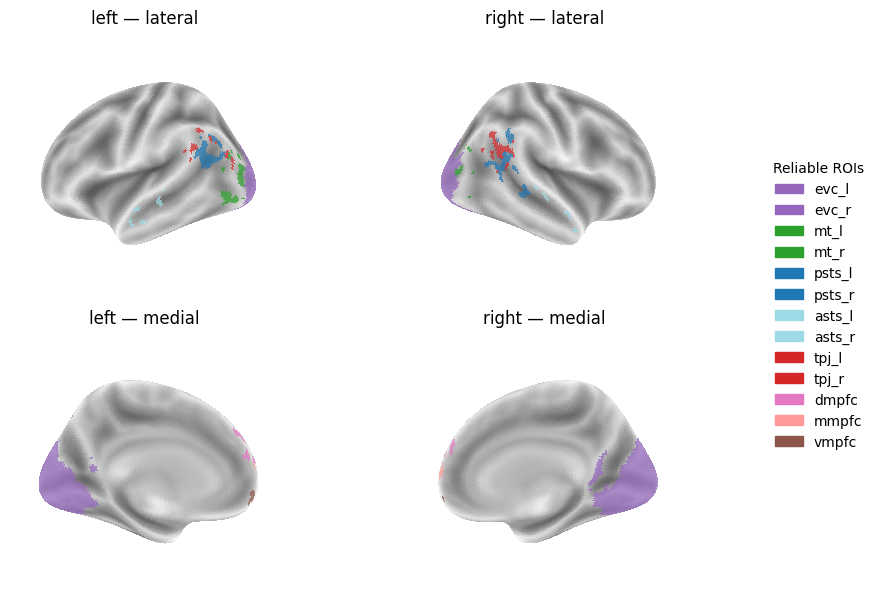

M10: Loaded saved ROIs


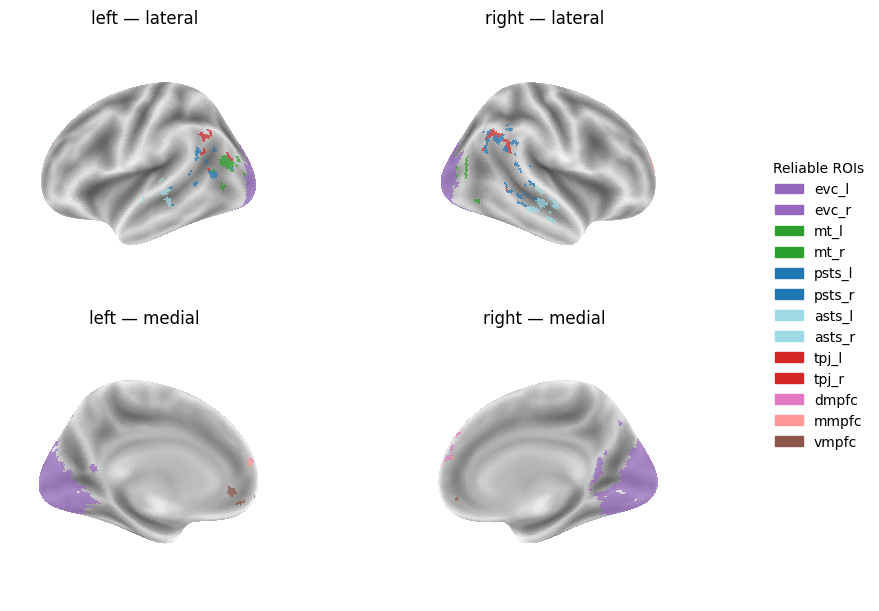

M11: Loaded saved ROIs


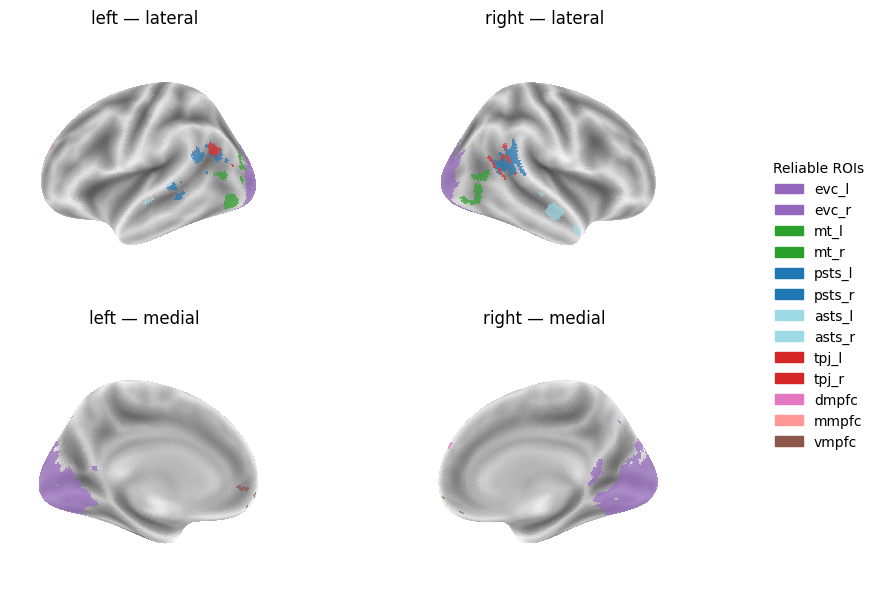

M12: Loaded saved ROIs


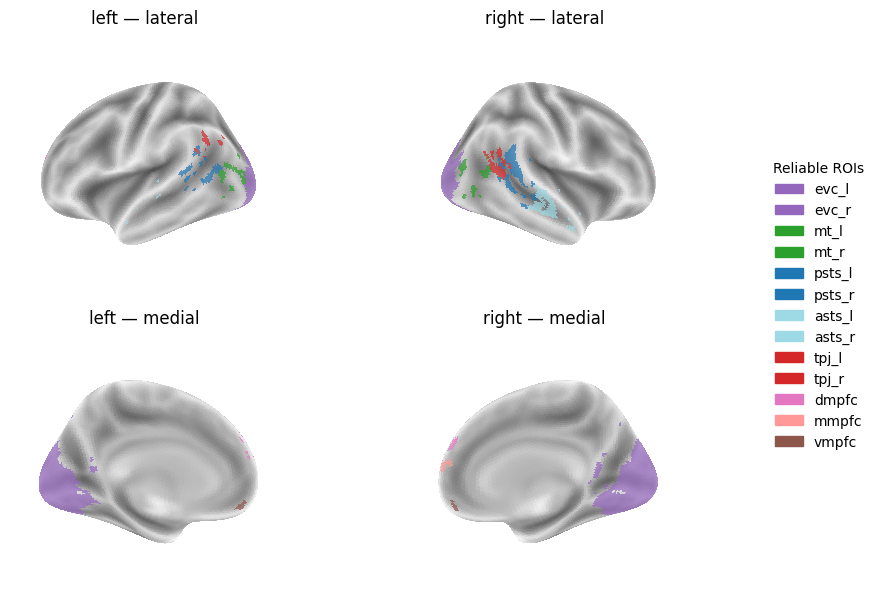

M13: Loaded saved ROIs


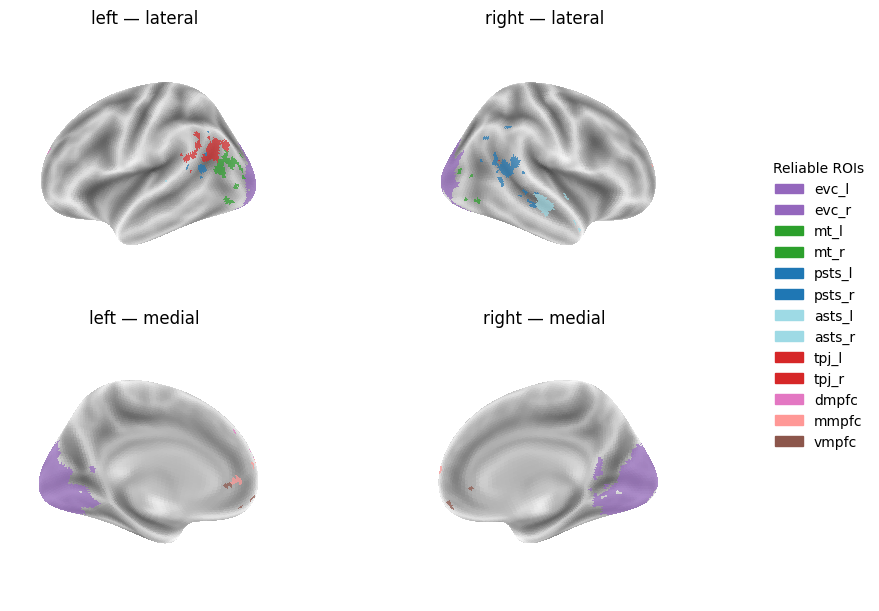

M15: Loaded saved ROIs


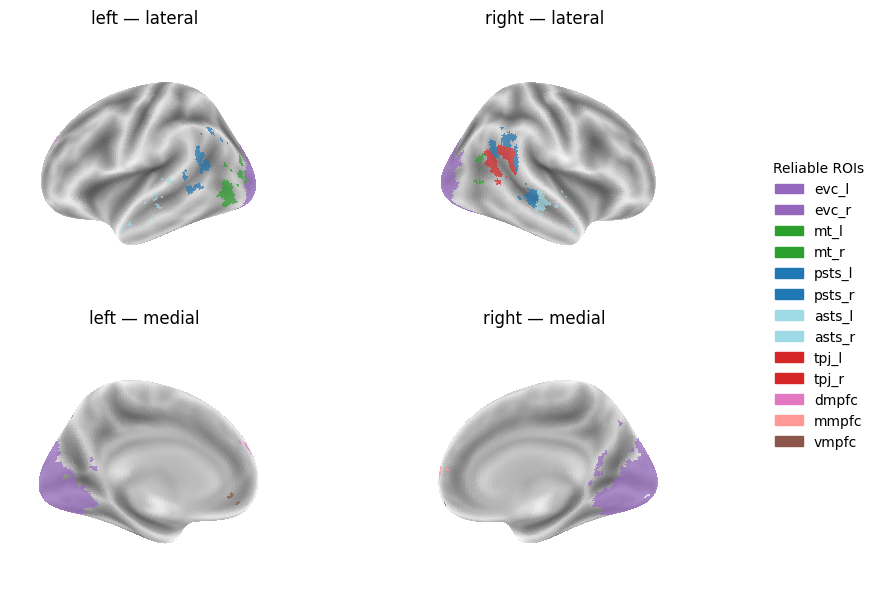

M17: Loaded saved ROIs


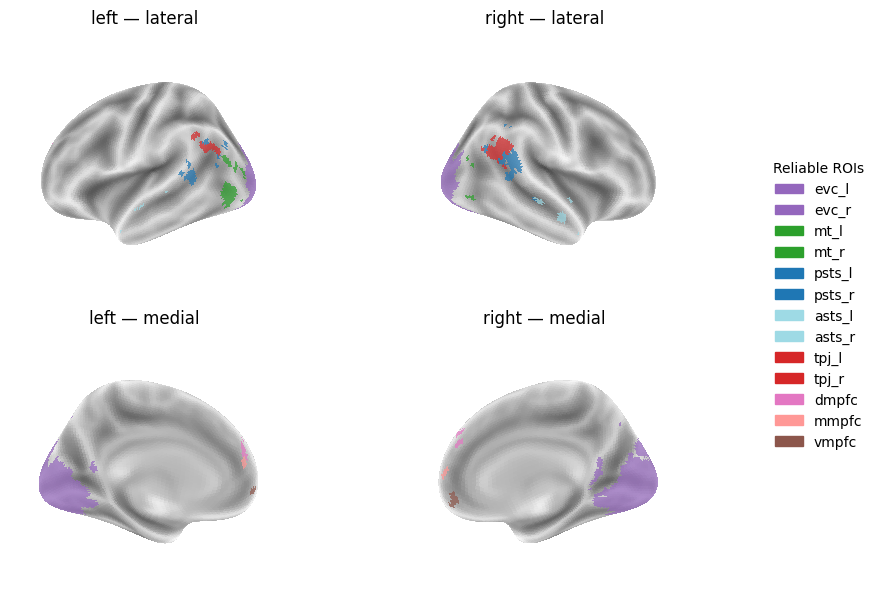

M18: Loaded saved ROIs


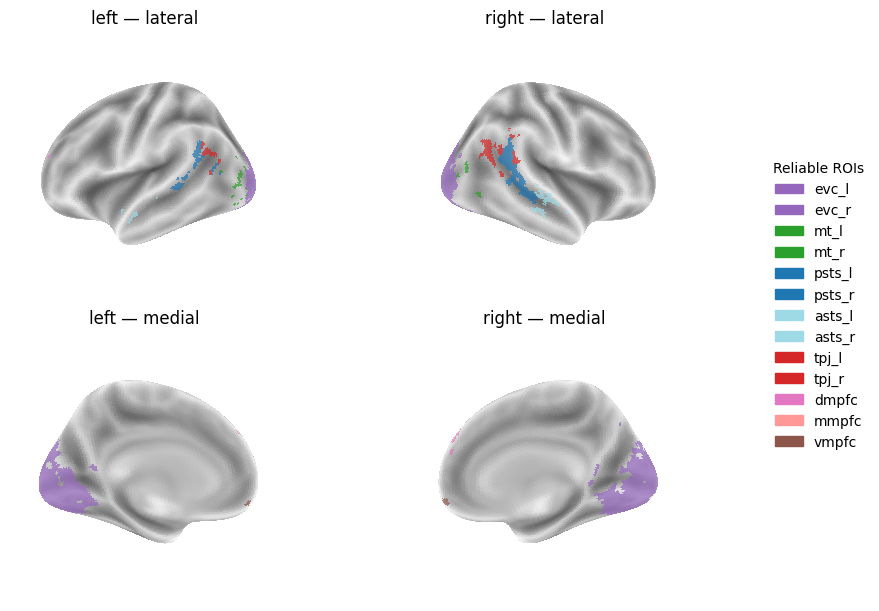

M19: Loaded saved ROIs


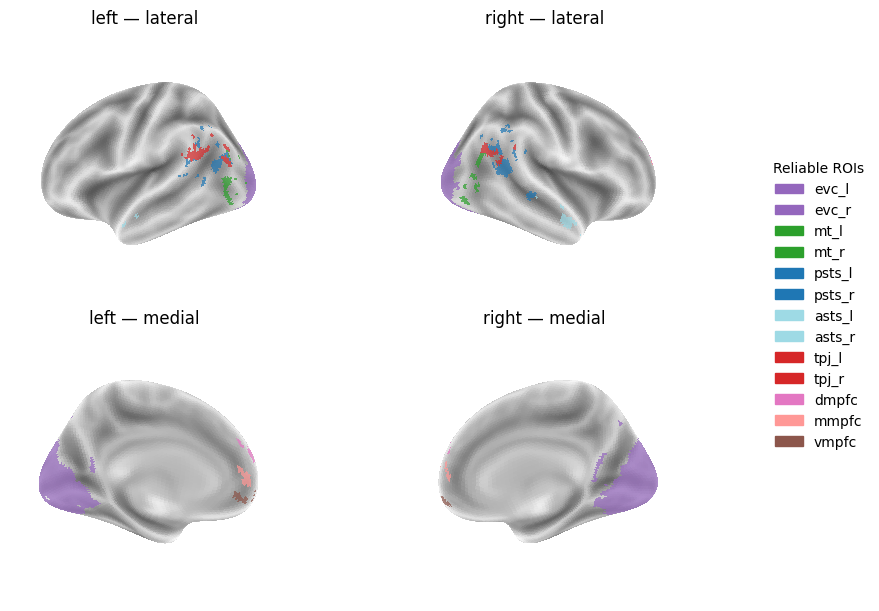

M20: Loaded saved ROIs


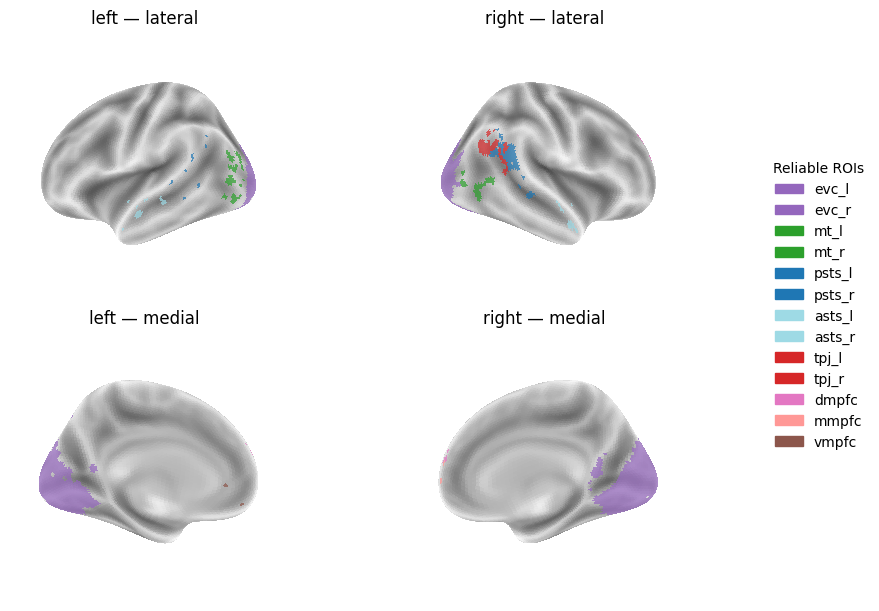

M21: Loaded saved ROIs


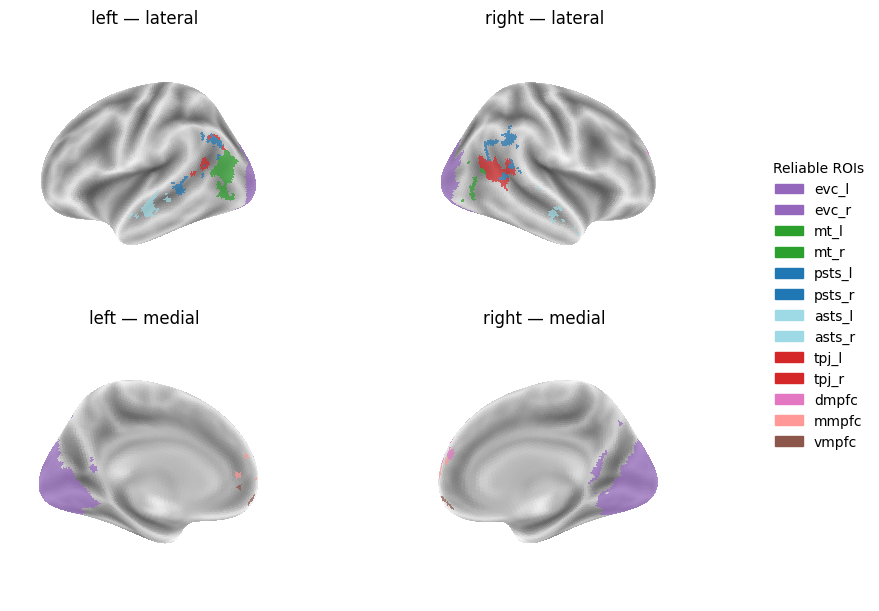

M22: Loaded saved ROIs


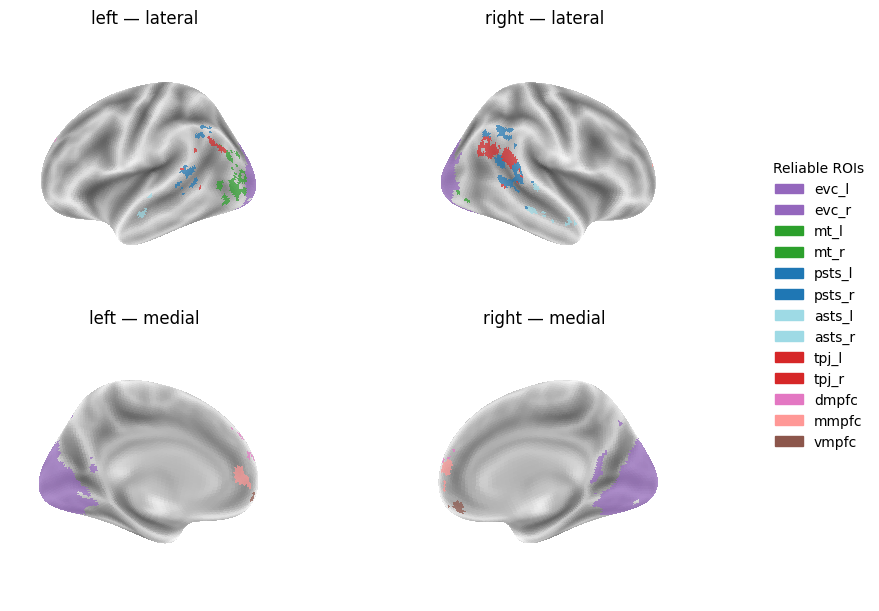

M23: Loaded saved ROIs


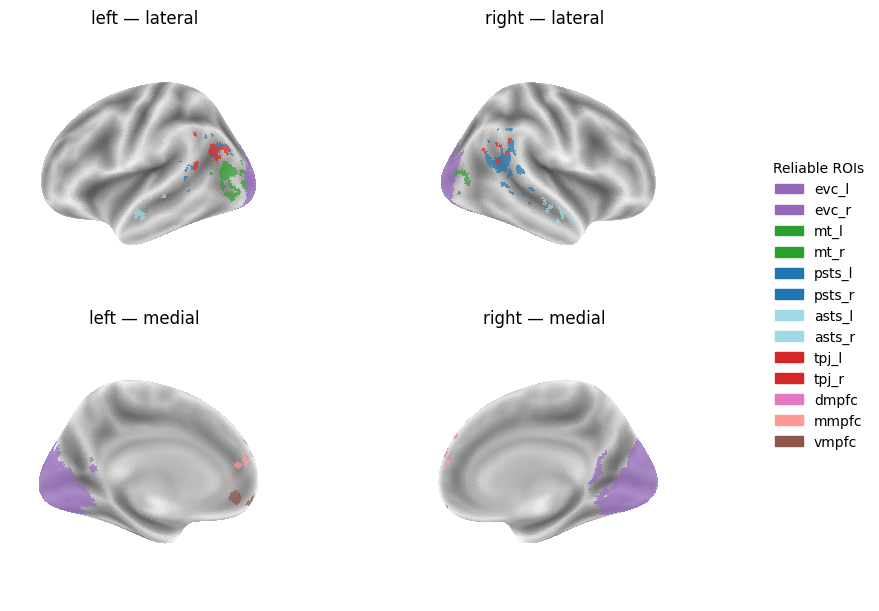

M24: Loaded saved ROIs


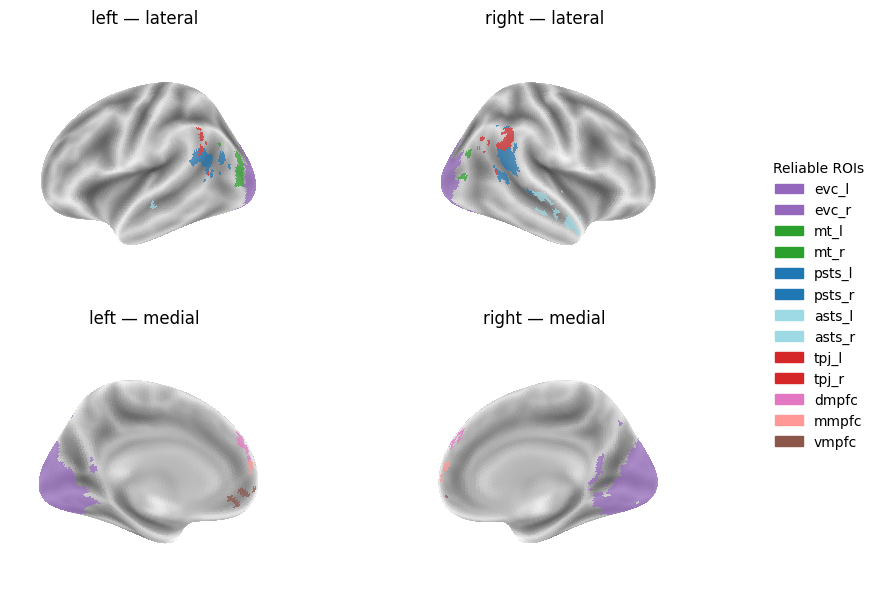

M25: Loaded saved ROIs


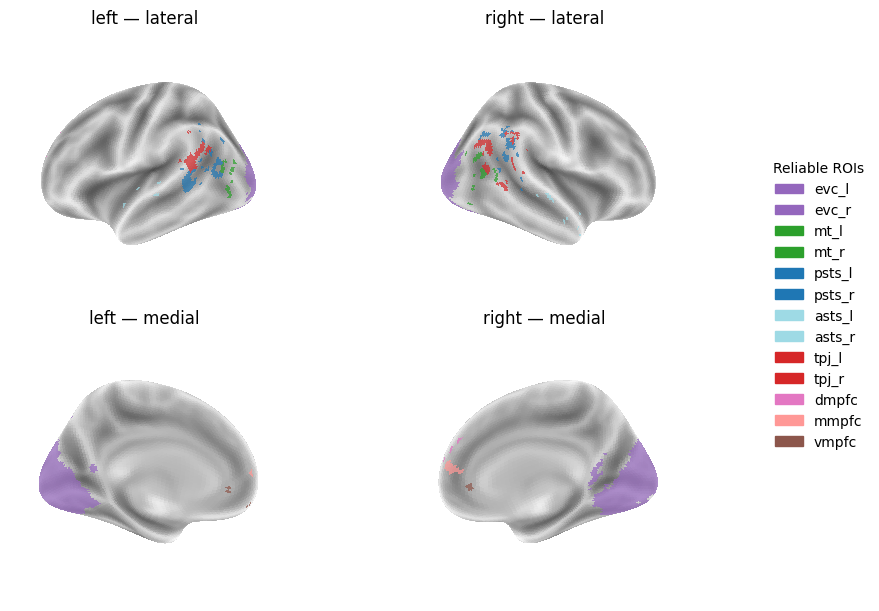

M26: Loaded saved ROIs


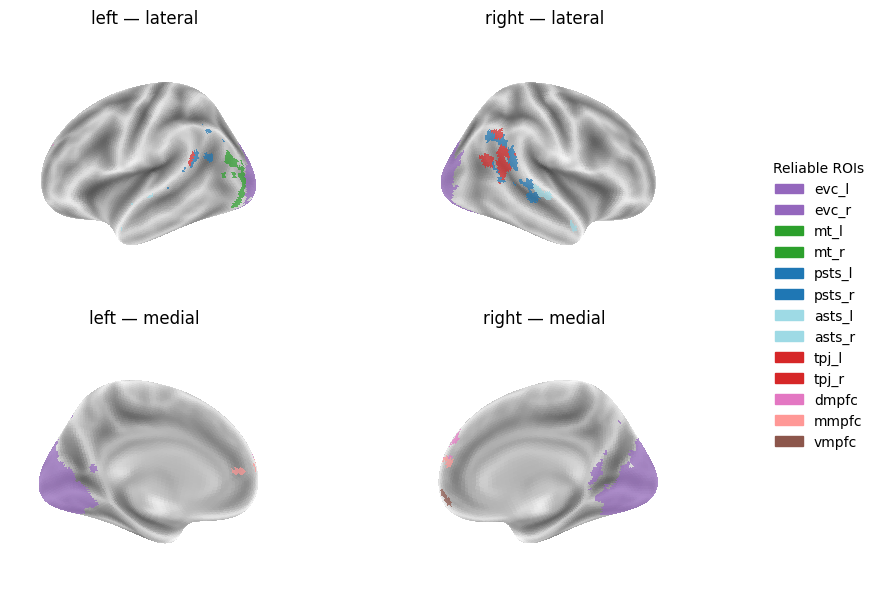

M27: Loaded saved ROIs


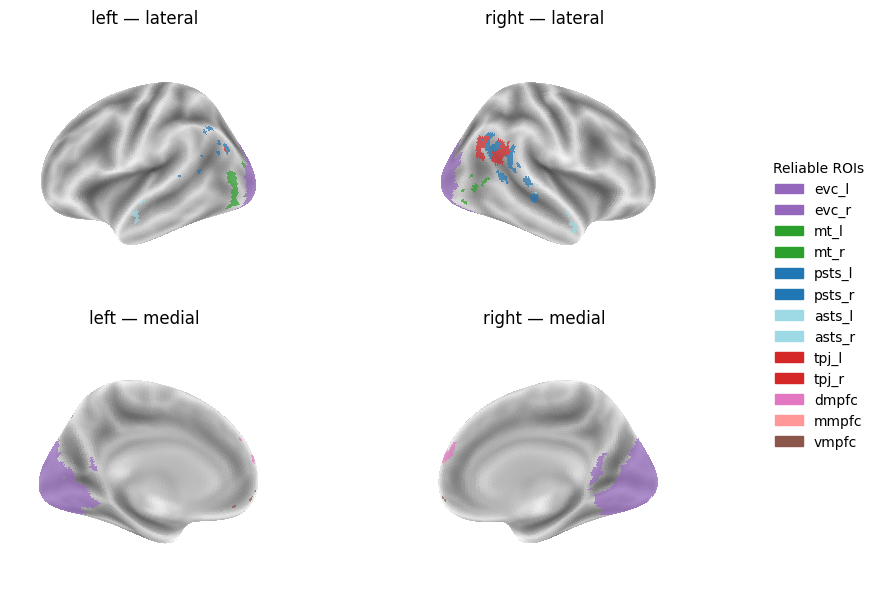

M28: Loaded saved ROIs


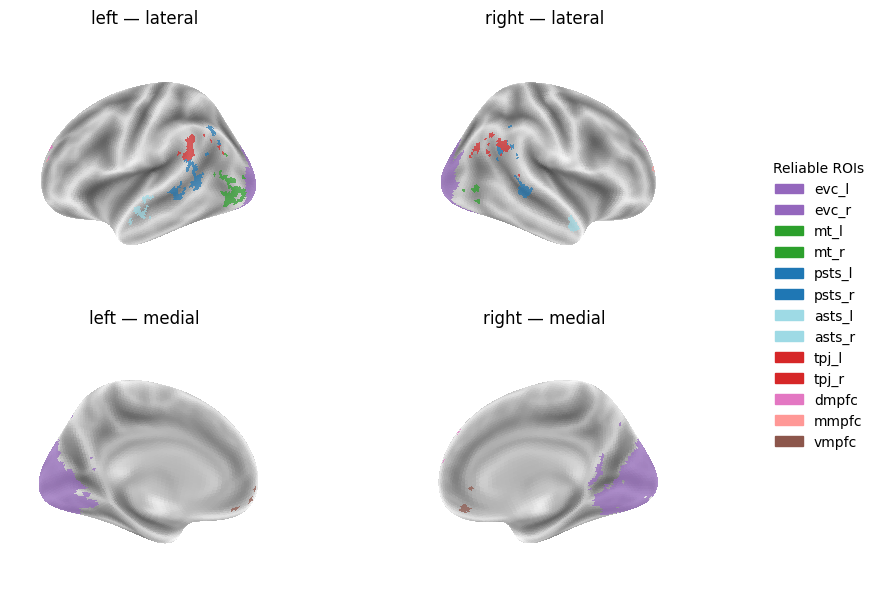

M29: Loaded saved ROIs


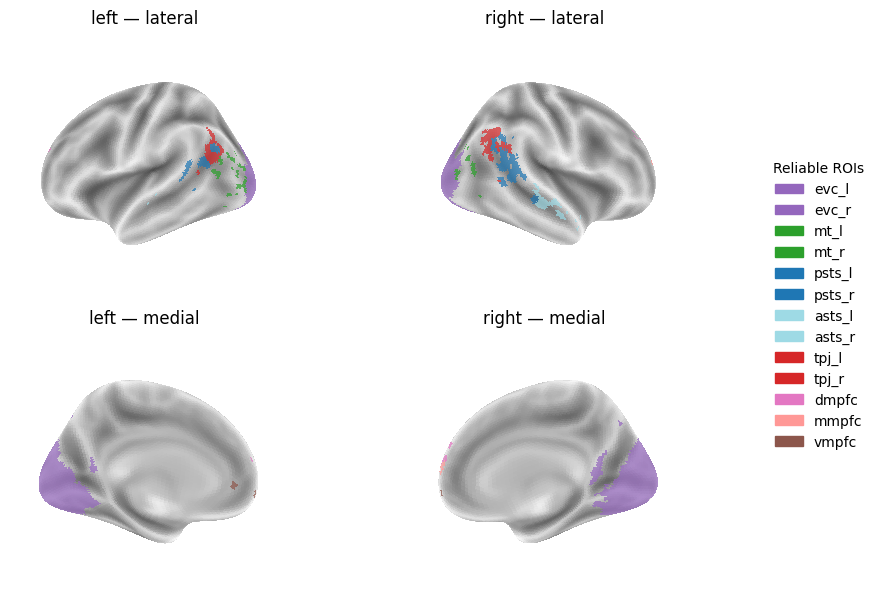

M30: Loaded saved ROIs


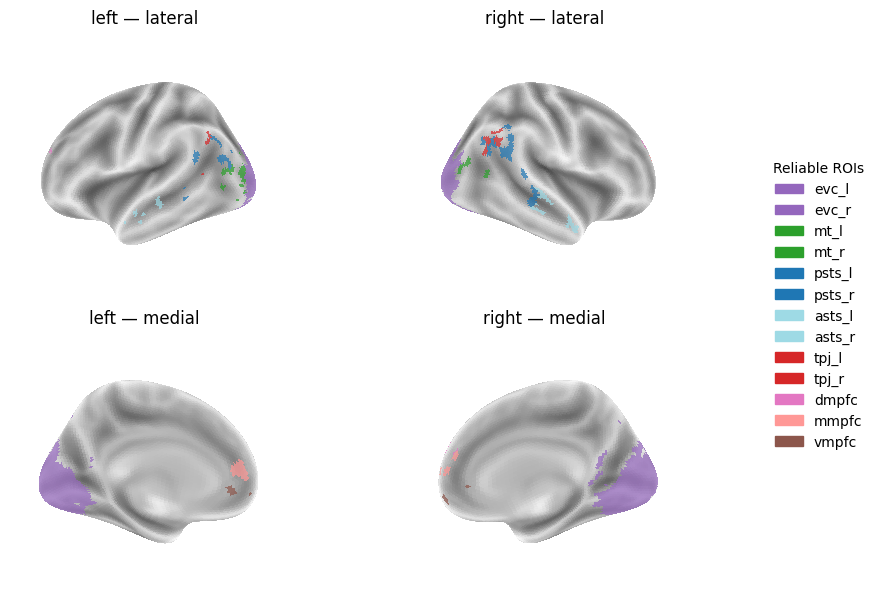

In [18]:
# reliable subject ROIs
roi_names_subj = ["evc_l", "evc_r", "mt_l", "mt_r", "psts_l", "psts_r", "asts_l", "asts_r",
   "tpj_l", "tpj_r", "dmpfc", "mmpfc", "vmpfc",]

sub_ids = ["M03", "M04", "M05", "M06", "M08", "M09", "M10", "M11", "M12", "M13", "M15", "M17", "M18", "M19", "M20","M21", "M22", "M23", "M24", "M25","M26", "M27", "M28", "M29", "M30"]

for sub_id in sub_ids:
    fs, aL, aR, nm = surf_atlas(sub_id=sub_id, source="subj_rois", names=roi_names_subj, overwrite= "first")
    plot_surf_atlas(fs, aL, aR, nm, title="Reliable ROIs")

## Mean DICE Coeffs

M03: Loaded saved ROIs
M04: Loaded saved ROIs
M05: Loaded saved ROIs
M06: Loaded saved ROIs
M08: Loaded saved ROIs
M09: Loaded saved ROIs
M10: Loaded saved ROIs
M11: Loaded saved ROIs
M12: Loaded saved ROIs
M13: Loaded saved ROIs
M15: Loaded saved ROIs
M17: Loaded saved ROIs
M18: Loaded saved ROIs
M19: Loaded saved ROIs
M20: Loaded saved ROIs
M21: Loaded saved ROIs
M22: Loaded saved ROIs
M23: Loaded saved ROIs
M24: Loaded saved ROIs
M25: Loaded saved ROIs
M26: Loaded saved ROIs
M27: Loaded saved ROIs
M28: Loaded saved ROIs
M29: Loaded saved ROIs
M30: Loaded saved ROIs


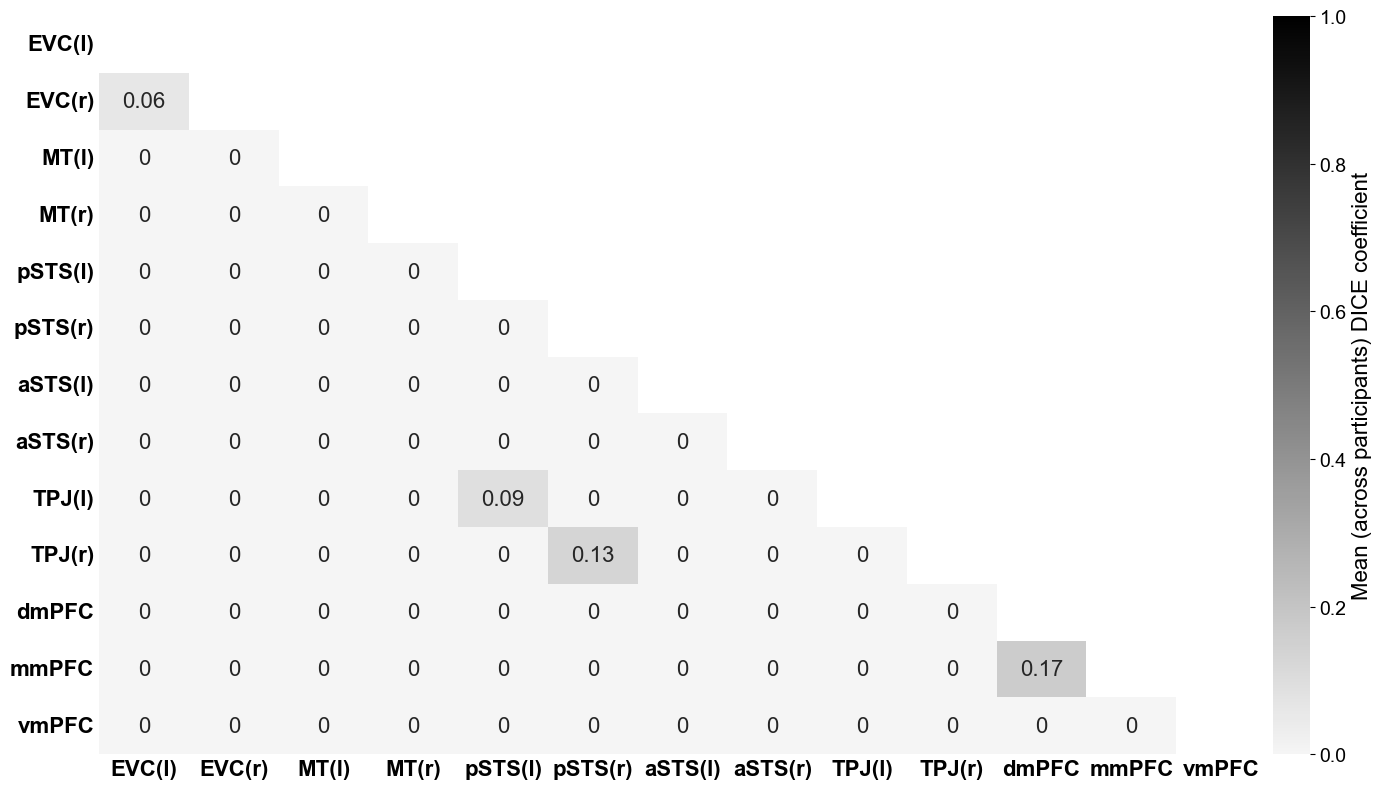

,ROI size (mean ± SD)
evc_l,2063.0 ± 0.0
evc_r,2276.0 ± 0.0
mt_l,76.0 ± 14.6
mt_r,33.9 ± 14.5
psts_l,71.9 ± 26.1
psts_r,106.1 ± 26.1
asts_l,32.8 ± 15.0
asts_r,64.6 ± 14.8
tpj_l,76.3 ± 37.8
tpj_r,125.7 ± 37.8


In [20]:
from createROIs import SubjROIs
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']


sub_ids = ["M03", "M04", "M05", "M06", "M08", "M09", "M10", "M11", "M12", "M13", "M15", "M17", "M18", "M19", "M20","M21", "M22", "M23", "M24", "M25","M26", "M27", "M28", "M29", "M30"]
roi_names = [ (None, "evc_l"),  (None, "evc_r"), ("sipsts",'mt_l'), ("sipsts",'mt_r'), 
		('sipsts','psts_l'), ('sipsts','psts_r'), 
		('sipsts','asts_l'), ('sipsts','asts_r'), ('tom','tpj_l'), ('tom','tpj_r'), 
		('tom','dmpfc'), ('tom','mmpfc'),('tom','vmpfc')]
overwrite = False

dice_dfs = []
roi_size_dfs = []
for sub_id in sub_ids:
    subjROIs = SubjROIs(sub_id, roi_names, overwrite=overwrite)
    # DICE
    dice_df = subjROIs.make_dice_coeff_table(roi_names, ax=None, plot=False)
    dice_dfs.append(dice_df)
    # Sizes
    sizes = subjROIs.get_roi_sizes()   # task -> roi_name -> size
    flat_sizes = {}
    for task, roi_dict in sizes.items():
        for roi_name, size in roi_dict.items():
            flat_sizes[roi_name] = size[0]
    roi_size_dfs.append(pd.Series(flat_sizes))
    
# average across subjects (ignores NaNs by default)
dice_mean = pd.concat(dice_dfs).groupby(level=0, sort=False).mean().round(2)

fig, ax = plt.subplots(figsize=(15, 8))
mask = np.triu(np.ones(dice_mean.shape, dtype=bool), k=1)

from matplotlib.colors import LinearSegmentedColormap
black_cmap = LinearSegmentedColormap.from_list(
    "black_cmap",
    ["#f5f5f5", "#000000"]
)

hm = sns.heatmap(dice_mean,mask=mask, cmap=black_cmap,annot=True, vmin=0,vmax=1, annot_kws={"size": 16}, cbar_kws={"pad": 0.005}, ax=ax)

cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Mean (across participants) DICE coefficient",fontsize=16)

#ax.set_title("Mean DICE coefficients across participants", fontweight=550) 

new_labels = [
    "EVC(l)", "EVC(r)","MT(l)", "MT(r)","pSTS(l)", "pSTS(r)","aSTS(l)", "aSTS(r)",
    "TPJ(l)", "TPJ(r)","dmPFC", "mmPFC", "vmPFC"]

ax.set_xticklabels(new_labels, rotation=0)
ax.set_yticklabels(new_labels, rotation=0)
ax.tick_params(axis='both', which='both', length=0)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight(550)
    label.set_fontsize(16)

plt.tight_layout()
plt.show()

# average sizes
roi_sizes_df = pd.concat(roi_size_dfs, axis=1)
mean = roi_sizes_df.mean(axis=1)
std  = roi_sizes_df.std(axis=1)
roi_order = dice_mean.index
roi_size_table = (
    mean.loc[roi_order].round(1).astype(str)
    + " ± "
    + std.loc[roi_order].round(1).astype(str)
).to_frame("ROI size (mean ± SD)")
roi_size_table
